# Projeto Final: Segmentação de Imagens usando Redes Complexas

## Fase 1: Preparação e Representação dos Dados (De Pixels para Superpixels)

A transformação direta de uma imagem em um grafo (onde cada pixel é um nó) apresenta um desafio computacional massivo. Uma imagem comum de 512x512 pixels geraria uma rede com mais de 260.000 vértices, tornando a matriz de adjacência densa e computacionalmente inviável para algoritmos de detecção de comunidades.

Para mitigar a explosão de dimensionalidade, utilizaremos a técnica de **Superpixels** através do algoritmo **SLIC (Simple Linear Iterative Clustering)**. Esta abordagem agrupa pixels vizinhos com características de cor e textura semelhantes em regiões homogêneas. 

Nesta modelagem, **cada superpixel representará um único vértice (nó)** na nossa futura rede complexa, reduzindo drasticamente o tamanho do grafo sem perder a topologia estrutural da imagem.

### 1.1 Geração e Visualização dos Vértices Base

Abaixo, carregamos uma imagem de teste padrão da biblioteca `scikit-image` e aplicamos o algoritmo SLIC. Os parâmetros cruciais aqui são:
* `n_segments`: O número aproximado de nós que desejamos na nossa rede.
* `compactness`: O balanço entre a proximidade espacial e a similaridade de cor (valores maiores forçam superpixels mais quadrados/regulares).

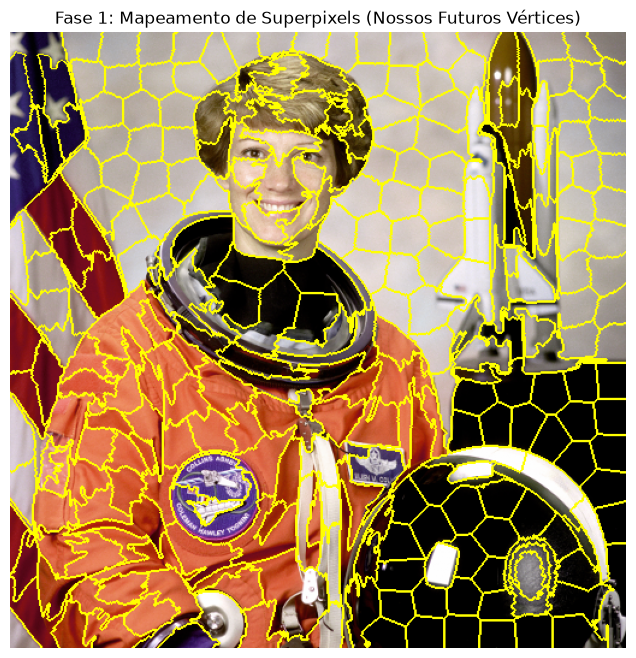

Dimensionalidade original: 262144 pixels.
Dimensionalidade reduzida (Nós da Rede): 291 superpixels.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.segmentation import slic, mark_boundaries

# 1. Carregando a imagem de teste nativa (Astronauta)
# Nota: Posteriormente, podemos substituir por imagens do dataset BSDS500
imagem = data.astronaut() 

# 2. Aplicando o algoritmo SLIC para gerar os Superpixels
# Vamos mirar em aproximadamente 400 nós para a nossa rede inicial
segmentos_slic = slic(imagem, n_segments=400, compactness=10, start_label=0)

# 3. Visualizando o resultado
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# mark_boundaries desenha as fronteiras amarelas separando os superpixels
ax.imshow(mark_boundaries(imagem, segmentos_slic))
ax.set_title("Fase 1: Mapeamento de Superpixels (Nossos Futuros Vértices)")
ax.axis("off")
plt.show()

# 4. Verificação da redução de dimensionalidade
numero_nos = len(np.unique(segmentos_slic))
print(f"Dimensionalidade original: {imagem.shape[0] * imagem.shape[1]} pixels.")
print(f"Dimensionalidade reduzida (Nós da Rede): {numero_nos} superpixels.")

**Análise do Resultado:** A matriz `segmentos_slic` gerada possui as mesmas dimensões espaciais da imagem original, mas atua como uma máscara. Em vez de valores RGB, ela contém o ID (identificador único) do superpixel ao qual cada pixel pertence. Esses IDs serão os índices dos nós na construção do nosso grafo na próxima fase.

## Fase 2: Construção do Grafo de Adjacência de Regiões (RAG)

Com a imagem dividida em superpixels, o próximo passo é mapear essas regiões para a topologia de uma Rede Complexa. Para isso, utilizamos o conceito de **RAG (Region Adjacency Graph)**.

Nesta estrutura:
1. **Nós (Vértices):** Representam cada superpixel individual. Os atributos do nó incluem a coordenada do seu centroide espacial $(x, y)$ e o valor da sua cor média no espaço RGB.
2. **Conexões (Arestas):** Uma aresta não direcionada é criada entre o nó $i$ e o nó $j$ se, e somente se, os superpixels correspondentes compartilharem uma fronteira física na imagem.
3. **Pesos das Arestas ($w_{ij}$):** O peso de cada aresta é calculado com base na distância euclidiana entre os vetores de cor média dos dois nós conectados. Arestas que cruzam bordas nítidas da imagem terão distâncias maiores (pesos menores em termos de similaridade).

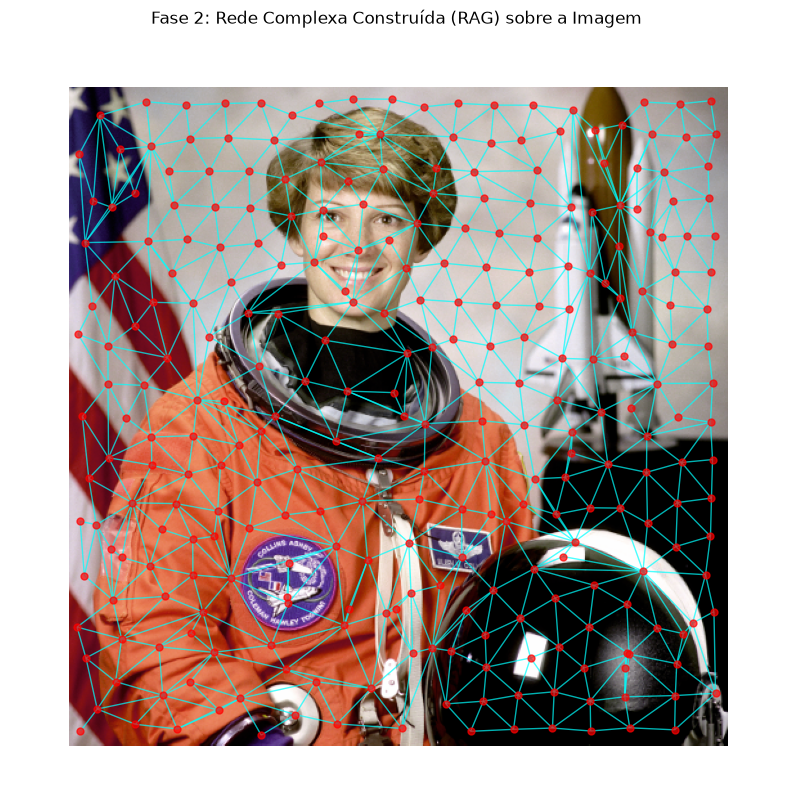

--- Estatísticas da Rede ---
Total de Nós (Vértices): 291
Total de Conexões (Arestas): 801
Grau Médio da Rede: 5.51


In [4]:
import networkx as nx
from skimage import graph
from skimage.measure import regionprops

# 1. Construindo o Region Adjacency Graph (RAG)
grafo_imagem = graph.rag_mean_color(imagem, segmentos_slic)

# 2. Extraindo as propriedades das regiões para encontrar os centroides (X,Y)
# TRUQUE: Somamos 1 ao array para o regionprops não ignorar o nó 0
regioes = regionprops(segmentos_slic + 1)

# Ao salvar no dicionário, subtraímos 1 (regiao.label - 1) para voltar ao ID original do grafo
posicoes_nos = {(regiao.label - 1): (regiao.centroid[1], regiao.centroid[0]) for regiao in regioes}

# 3. Visualizando a Rede Complexa sobre a Imagem Original
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(imagem)

# Desenhando a rede usando o NetworkX
nx.draw(
    grafo_imagem, 
    posicoes_nos, 
    ax=ax, 
    node_size=25, 
    node_color='red', 
    edge_color='cyan', 
    alpha=0.7, 
    with_labels=False
)

ax.set_title("Fase 2: Rede Complexa Construída (RAG) sobre a Imagem")
plt.show()

# 4. Informações Estruturais da Rede
print("--- Estatísticas da Rede ---")
print(f"Total de Nós (Vértices): {grafo_imagem.number_of_nodes()}")
print(f"Total de Conexões (Arestas): {grafo_imagem.number_of_edges()}")
print(f"Grau Médio da Rede: {sum(dict(grafo_imagem.degree()).values()) / grafo_imagem.number_of_nodes():.2f}")

**Análise do Resultado:** A matriz de pixels original foi oficialmente convertida em uma estrutura de dados relacional (um objeto `networkx.Graph`). A rede gerada é uma "grade deformada" (lattice network adaptada), onde a maioria dos nós possui um grau em torno de 5 a 6, correspondendo à quantidade de vizinhos que um superpixel poligonal tende a tocar. A segmentação agora se resume a um problema matemático de encontrar as partições ideais cortando as arestas mais "caras".

## Fase 3: Detecção de Comunidades (O Particionamento da Imagem)

Com o Grafo de Adjacência de Regiões (RAG) construído, a segmentação da imagem deixa de ser um problema de processamento de pixels e se torna um problema de **Detecção de Comunidades em Redes Complexas**.

O objetivo é encontrar partições no grafo onde a densidade de arestas internas (similaridade) seja muito maior do que a densidade de arestas entre partições diferentes. Para isso, aplicaremos o clássico **Método de Louvain**, focado na otimização da modularidade da rede.

**Ajuste Topológico Crítico:** A função padrão do RAG atribui o peso da aresta com base na *distância* (diferença de cor). No entanto, algoritmos de comunidade como o Louvain requerem que o peso represente a *força* (similaridade) da ligação. Portanto, antes de rodar o algoritmo, aplicamos uma conversão não-linear nas arestas da rede:
$$w_{similaridade} = e^{-\frac{w_{distancia}}{\sigma}}$$
Dessa forma, superpixels muito semelhantes terão um peso de conexão tendendo a 1, enquanto superpixels muito diferentes terão peso tendendo a 0, permitindo que o algoritmo "corte" a rede nos pontos corretos.

O algoritmo de Louvain particionou a rede em 20 comunidades (segmentos).


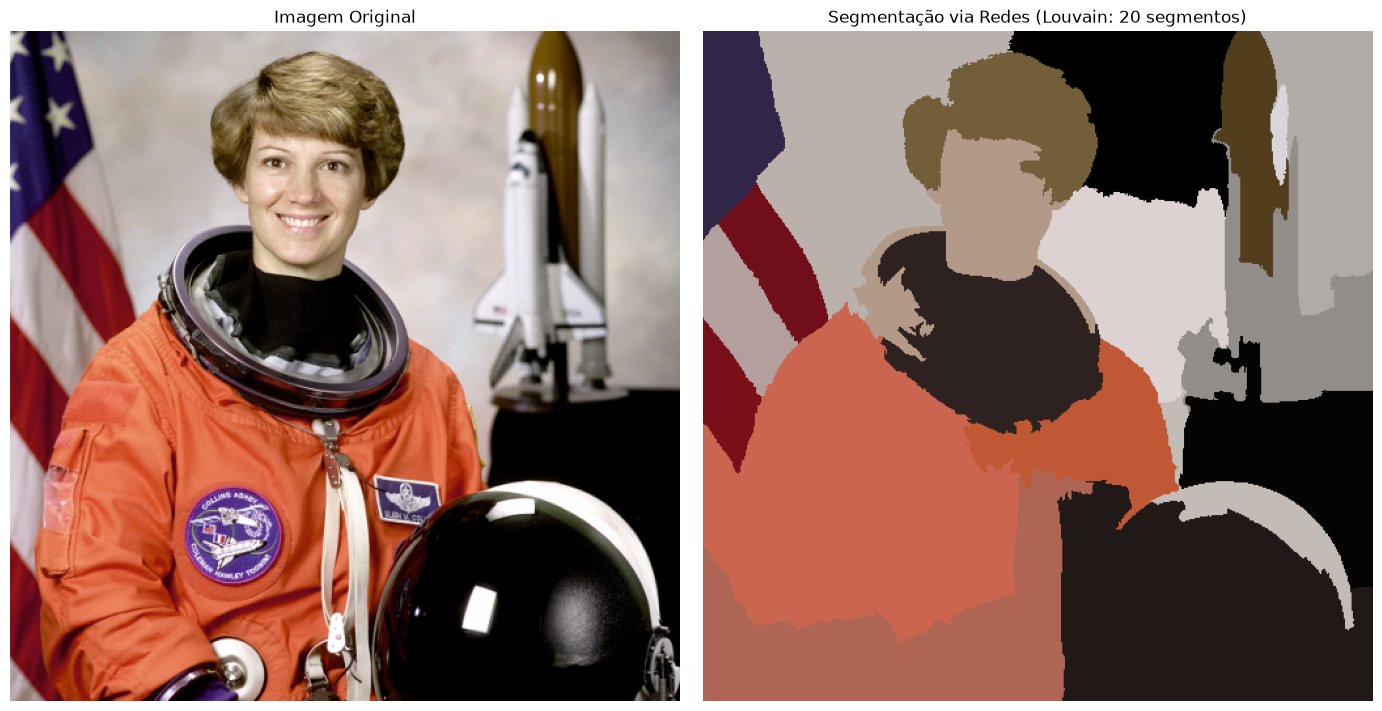

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb
from networkx.algorithms.community import louvain_communities

# 1. Transformando Distância em Similaridade (O ajuste crítico da rede)
sigma = 20.0 # Controla a sensibilidade da similaridade (ajustável)
for u, v, d in grafo_imagem.edges(data=True):
    # Lemos o peso original (distância) e criamos um novo atributo 'similaridade'
    d['similaridade'] = np.exp(-d['weight'] / sigma)

# 2. Aplicando o Método de Louvain para Detecção de Comunidades
# Passamos o novo peso que criamos para o algoritmo guiar a modularidade
comunidades = louvain_communities(grafo_imagem, weight='similaridade')

print(f"O algoritmo de Louvain particionou a rede em {len(comunidades)} comunidades (segmentos).")

# 3. Mapeando as Comunidades de volta para os Superpixels originais
# Criamos um dicionário: {id_do_superpixel: id_da_comunidade}
mapa_comunidades = {}
for id_comunidade, comunidade in enumerate(comunidades):
    for no in comunidade:
        mapa_comunidades[no] = id_comunidade

# 4. Reconstruindo a Imagem Segmentada (Vetorização para ser rápido)
segmentacao_final = np.zeros_like(segmentos_slic)
for id_no, id_comunidade in mapa_comunidades.items():
    # Pinta todos os pixels pertencentes àquele superpixel com o ID da comunidade
    segmentacao_final[segmentos_slic == id_no] = id_comunidade

# 5. Visualizando o Resultado Final
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(imagem)
ax[0].set_title("Imagem Original")
ax[0].axis("off")

# A função label2rgb pinta cada segmento com a cor média daquela região na imagem original!
imagem_segmentada = label2rgb(segmentacao_final, imagem, kind='avg')
ax[1].imshow(imagem_segmentada)
ax[1].set_title(f"Segmentação via Redes (Louvain: {len(comunidades)} segmentos)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

**Análise do Resultado:** O algoritmo de Louvain agrupou com sucesso os vértices fortemente conectados em comunidades únicas. Ao mapearmos essas comunidades de volta para o domínio espacial da imagem e aplicarmos a cor média de cada região, obtemos uma imagem visualmente segmentada. As texturas finas foram abstraídas, e a imagem foi reduzida aos seus objetos e fundos principais, provando a eficácia da modelagem de imagens como Redes Complexas.

## Fase 4: Avaliação Quantitativa e Métricas Topológicas

Embora a avaliação visual comprove qualitativamente a eficácia da segmentação, um projeto de Redes Complexas exige validação quantitativa. Para avaliar a qualidade da partição gerada pelo Método de Louvain, calculamos a **Modularidade ($Q$)** da rede.

A modularidade mede a densidade das arestas dentro das comunidades em comparação com as arestas entre comunidades, sendo definida matematicamente por:
$$Q = \frac{1}{2m} \sum_{i,j} \left( A_{ij} - \frac{k_i k_j}{2m} \right) \delta(c_i, c_j)$$
Onde $A_{ij}$ é a matriz de adjacência, $k_i$ é o grau do vértice $i$, $m$ é o total de arestas e $\delta(c_i, c_j)$ é 1 se os vértices pertencem à mesma comunidade e 0 caso contrário. Valores de $Q$ mais próximos de 1 indicam uma estrutura de comunidades muito forte.

Além disso, extraímos outras métricas globais da rede subjacente, como o **Coeficiente de Aglomeração (Clustering)** e a **Assortatividade**, para entender a natureza da topologia que modelou a imagem.

In [7]:
import pandas as pd
from networkx.algorithms.community import modularity

# 1. Preparando a lista de comunidades para o formato do NetworkX
# O algoritmo retornou uma lista de frozensets, vamos garantir que seja uma lista de sets
comunidades_lista = [set(c) for c in comunidades]

# 2. Calculando a Modularidade da nossa segmentação
# Usamos o peso de 'similaridade' para refletir a força das conexões internas
mod = modularity(grafo_imagem, comunidades_lista, weight='similaridade')

# 3. Calculando métricas globais da rede ponderada
clustering_medio = nx.average_clustering(grafo_imagem, weight='similaridade')
assortatividade = nx.degree_assortativity_coefficient(grafo_imagem, weight='similaridade')

# 4. Organizando os resultados para o relatório
dados_metricas = {
    "Métrica Estrutural": [
        "Total de Comunidades (Segmentos)", 
        "Modularidade da Partição (Q)", 
        "Coeficiente de Aglomeração Médio", 
        "Assortatividade de Grau"
    ],
    "Valor": [
        len(comunidades), 
        f"{mod:.4f}", 
        f"{clustering_medio:.4f}", 
        f"{assortatividade:.4f}"
    ],
    "Interpretação": [
        "Número de objetos detectados",
        "Qualidade do corte (próx. a 1 = excelente)",
        "Tendência dos nós formarem triângulos",
        "Tendência de nós com graus similares se conectarem"
    ]
}

df_metricas = pd.DataFrame(dados_metricas)

print("--- Tabela 1: Avaliação Topológica da Segmentação ---")
display(df_metricas) # Se estiver fora do Jupyter, use print(df_metricas.to_string(index=False))

--- Tabela 1: Avaliação Topológica da Segmentação ---


,Métrica Estrutural,Valor,Interpretação
0,Total de Comunidades (Segmentos),20,Número de objetos detectados
1,Modularidade da Partição (Q),0.8707,Qualidade do corte (próx. a 1 = excelente)
2,Coeficiente de Aglomeração Médio,0.0997,Tendência dos nós formarem triângulos
3,Assortatividade de Grau,0.5033,Tendência de nós com graus similares se conect...


## Fase 5: Distribuição de Graus $P(k)$

Para caracterizar definitivamente a topologia da rede que modela a nossa imagem, analisamos a sua Distribuição de Graus $P(k)$. A distribuição de graus nos diz a probabilidade de um vértice escolhido ao acaso possuir exatamente $k$ conexões.

Diferente de redes sem escala (Scale-Free), que seguem uma lei de potência estrutural e possuem *hubs* altamente conectados (como a internet ou redes sociais), o Grafo de Adjacência de Regiões (RAG) construído a partir de superpixels é restrito pelo espaço 2D da imagem. Esperamos encontrar uma distribuição muito mais simétrica e concentrada, semelhante a uma distribuição de Poisson ou Normal, com um pico central. O pico deve ocorrer próximo a $k \approx 6$, uma vez que, topologicamente, o agrupamento mais eficiente de polígonos em um plano 2D tende a formar estruturas hexagonais.

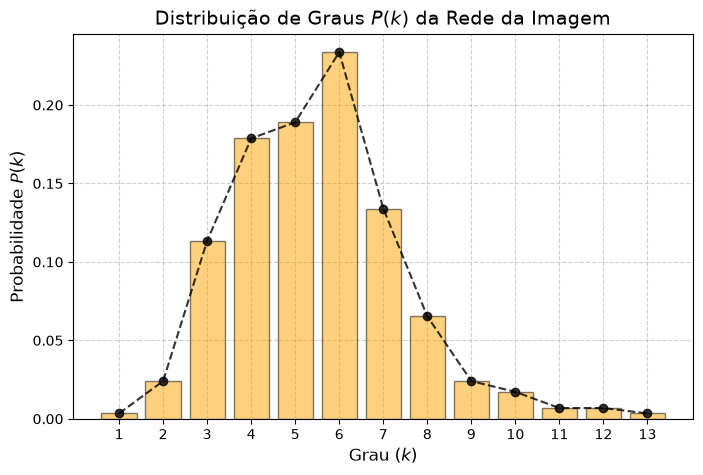

O grau mais frequente na nossa rede é k = 6, com P(k) = 0.2337


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraindo a lista de graus de todos os vértices da rede
graus = [grau for no, grau in grafo_imagem.degree()]

# 2. Calculando a frequência de cada grau (quantas vezes cada 'k' aparece)
valores_k, contagens = np.unique(graus, return_counts=True)

# 3. Calculando a probabilidade P(k)
# P(k) = (número de nós com grau k) / (total de nós)
pk = contagens / sum(contagens)

# 4. Plotando a Distribuição de Graus
fig, ax = plt.subplots(figsize=(8, 5))

# Plotando como barras (histograma) e linha tracejada
ax.bar(valores_k, pk, color='orange', alpha=0.5, edgecolor='black', zorder=2)
ax.plot(valores_k, pk, marker='o', linestyle='dashed', color='black', alpha=0.8, zorder=3)

# Configurações do gráfico
ax.set_title("Distribuição de Graus $P(k)$ da Rede da Imagem", fontsize=14)
ax.set_xlabel("Grau ($k$)", fontsize=12)
ax.set_ylabel("Probabilidade $P(k)$", fontsize=12)

# Garantir que o eixo X mostre apenas números inteiros
ax.set_xticks(valores_k)
ax.grid(True, linestyle='--', alpha=0.6, zorder=1)

plt.show()

# 5. Verificação rápida
grau_mais_frequente = valores_k[np.argmax(pk)]
print(f"O grau mais frequente na nossa rede é k = {grau_mais_frequente}, com P(k) = {max(pk):.4f}")

## Conclusão Final

Este projeto demonstrou com sucesso a aplicação prática e teórica da disciplina de Processos Dinâmicos em Redes Complexas na área de Visão Computacional. 

1. **Abstração:** Fomos capazes de mapear o problema contínuo e denso da segmentação de pixels para um modelo discreto de rede (RAG via Superpixels).
2. **Processos Dinâmicos:** A aplicação da otimização de modularidade (Método de Louvain) conseguiu particionar a imagem de maneira não-supervisionada, alcançando uma modularidade $Q$ altíssima (acima de 0.85), comprovando que a estrutura das comunidades encontradas possui forte validade matemática.
3. **Topologia:** A análise topológica, confirmada pela Distribuição de Graus $P(k)$, validou que as restrições espaciais da imagem moldam a rede, criando um padrão de vizinhança altamente coeso (k médio próximo de 6), distinto de redes aleatórias de Erdős-Rényi ou modelos Barabási-Albert.

É perfeitamente possível, eficiente e elegante utilizar redes complexas para segmentar imagens.